In [24]:
import pandas as pd
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import MinMaxScaler
import scipy.cluster.hierarchy as shc
import matplotlib.pyplot as plt
import matplotlib.patheffects as PathEffects
import seaborn as sns
import numpy as np

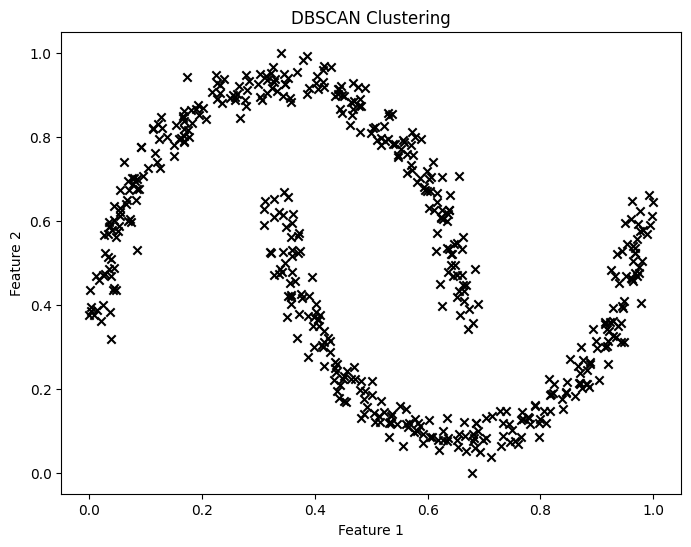

In [25]:
# generate 1000 2d points
from sklearn.datasets import make_moons
X, y = make_moons(n_samples=500, noise=0.05, random_state=0)
# scale the data to [0, 1]
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
# fit the model
clusters = [-1] * len(X_scaled)  # Cluster labels for each point

def plot_clusters(X, clusters):
    plt.figure(figsize=(8, 6))
    for i in range(len(clusters)):
        if clusters[i] == -1:
            plt.scatter(X_scaled[i, 0], X_scaled[i, 1], c='k', marker='x')
        else:
            plt.scatter(X_scaled[i, 0], X_scaled[i, 1], c=plt.cm.Set1(clusters[i] / max(clusters)), marker='o')
    plt.title('DBSCAN Clustering')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.show()

plot_clusters(X_scaled, clusters)

In [26]:
class HDBSCAN:
    def __init__(self, min_samples=5, min_cluster_size=5):
        self.min_samples = min_samples
        self.min_cluster_size = min_cluster_size
        self.labels_ = None

    def fit(self, X):
        n_samples = X.shape[0]
        
        # Step 1: Build mutual reachability graph
        # Compute k-distance (distance to k-th nearest neighbor)
        from scipy.spatial.distance import cdist
        distances = cdist(X, X)
        
        # Sort distances and get k-th distance for each point
        k_distances = np.sort(distances, axis=1)[:, self.min_samples]
        
        # Calculate core distances
        core_distances = k_distances
        
        # Build mutual reachability distance matrix
        mrd = np.zeros((n_samples, n_samples))
        for i in range(n_samples):
            for j in range(n_samples):
                if i != j:  # Diagonal must be 0
                    mrd[i, j] = max(distances[i, j], core_distances[i], core_distances[j])
        
        # Step 2: Build MST (Minimum Spanning Tree) using Prim's algorithm
        from scipy.spatial.distance import squareform
        from scipy.cluster.hierarchy import linkage
        
        # Convert to condensed distance matrix
        mrd_condensed = squareform(mrd)
        
        # Apply hierarchical clustering using single linkage
        Z = linkage(mrd_condensed, method='single')
        
        # Step 3: Build hierarchical clustering dendrogram
        # Z contains the dendrogram information
        
        # Step 4: Extract clusters from dendrogram
        from scipy.cluster.hierarchy import fcluster
        
        # Extract clusters using a distance threshold
        # We'll use a method based on the longest edge in the MST
        clusters = fcluster(Z, t=2*np.max(k_distances), criterion='distance')
        
        # Step 5: Assign noise points
        # Points in small clusters are labeled as noise
        self.labels_ = np.full(n_samples, -1)
        
        unique_clusters = np.unique(clusters)
        cluster_id = 0
        
        for cluster_label in unique_clusters:
            cluster_members = np.where(clusters == cluster_label)[0]
            
            if len(cluster_members) >= self.min_cluster_size:
                self.labels_[cluster_members] = cluster_id
                cluster_id += 1
            else:
                # Small clusters are marked as noise (-1)
                self.labels_[cluster_members] = -1
        
        return self
    
    def fit_predict(self, X):
        self.fit(X)
        return self.labels_

In [27]:
# Test HDBSCAN implementation
hdbscan = HDBSCAN(min_samples=5, min_cluster_size=5)
labels = hdbscan.fit_predict(X_scaled)

print(f"Number of clusters: {len(set(labels)) - (1 if -1 in labels else 0)}")
print(f"Number of noise points: {np.sum(labels == -1)}")
print(f"Cluster labels: {np.unique(labels)}")

Number of clusters: 2
Number of noise points: 0
Cluster labels: [0 1]


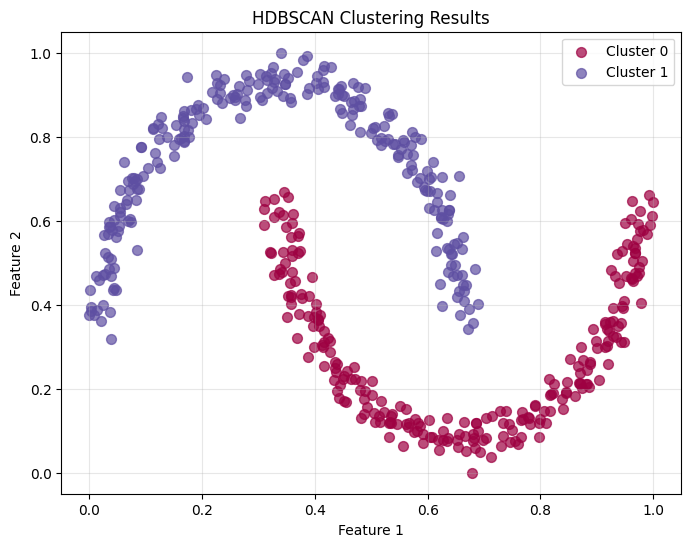

In [28]:
# Visualize HDBSCAN results
plt.figure(figsize=(8, 6))
unique_labels = set(labels)
colors = plt.cm.Spectral(np.linspace(0, 1, len(unique_labels)))

for label, color in zip(unique_labels, colors):
    if label == -1:
        # Noise points in black
        color = 'black'
        marker = 'x'
    else:
        marker = 'o'
    
    class_member_mask = (labels == label)
    xy = X_scaled[class_member_mask]
    plt.scatter(xy[:, 0], xy[:, 1], c=[color], marker=marker, s=50, alpha=0.7,
                label=f'Cluster {label}' if label != -1 else 'Noise')

plt.title('HDBSCAN Clustering Results')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Giải thích chi tiết các bước 3, 4, 5 của HDBSCAN

## **Bước 3: Build Hierarchical Clustering Dendrogram**
```
Input: Ma trận linkage Z từ hierarchical clustering
Output: Cấu trúc dendrogram (biểu diễn phân cấp)
```

### Chi tiết:
- **Ma trận Z (linkage matrix)**: Chứa thông tin về cách các cluster được kết hợp
- **Cấu trúc**: Mỗi hàng trong Z có dạng `[i, j, distance, cluster_size]`
  - `i, j`: Hai cluster được kết hợp
  - `distance`: Khoảng cách giữa hai cluster (single linkage)
  - `cluster_size`: Số điểm trong cluster kết hợp

**Ví dụ:**
```
Z[0] = [5, 10, 0.15, 2]  → Kết hợp điểm 5 và 10, khoảng cách 0.15
Z[1] = [0, 15, 0.25, 3]  → Kết hợp cluster từ Z[0] với điểm 15, khoảng cách 0.25
```

### Trực quan:
```
          cluster 3 (khoảng cách 0.40)
         /                    \
    cluster 2               cluster 1
    (0.25)                  (0.15)
     /  \                    /  \
    5   10                  20   25
```

---

## **Bước 4: Extract Clusters from Dendrogram**
```
Input: Ma trận Z, ngưỡng khoảng cách (distance threshold)
Output: Nhãn cluster tạm thời cho mỗi điểm
```

### Chi tiết:
```python
clusters = fcluster(Z, t=2*np.max(k_distances), criterion='distance')
```

**Giải thích từng phần:**
1. **Ngưỡng khoảng cách `t = 2*np.max(k_distances)`**:
   - `np.max(k_distances)`: Khoảng cách trung bình lớn nhất đến k-th nearest neighbor
   - Nhân 2: Để tạo ra ngưỡng hợp lý cho việc cắt dendrogram
   - Ngưỡng cao → ít cluster, Ngưỡng thấp → nhiều cluster

2. **Tiêu chí `criterion='distance'`**:
   - Cắt dendrogram dựa trên **ngưỡng khoảng cách** thay vì số lượng cluster
   - Tại mỗi bước kết hợp có khoảng cách > t, ta giữ lại cluster riêng biệt

### Ví dụ cụ thể:
```
Giả sử: t = 0.30

Dendrogram:
0.15 → Kết hợp điểm 5, 10 (< 0.30) ✓ Cùng cluster
0.25 → Kết hợp {5,10} với 15 (< 0.30) ✓ Cùng cluster
0.40 → Kết hợp {5,10,15} với {20,25} (> 0.30) ✗ Cluster khác nhau

Kết quả:
- Cluster A: {5, 10, 15}
- Cluster B: {20, 25}
```

---

## **Bước 5: Assign Noise Points**
```python
# Assign noise points
self.labels_ = np.full(n_samples, -1)

unique_clusters = np.unique(clusters)
cluster_id = 0

for cluster_label in unique_clusters:
    cluster_members = np.where(clusters == cluster_label)[0]
    
    if len(cluster_members) >= self.min_cluster_size:
        self.labels_[cluster_members] = cluster_id
        cluster_id += 1
    else:
        # Small clusters are marked as noise (-1)
        self.labels_[cluster_members] = -1
```

### Chi tiết:
1. **Khởi tạo**: Tất cả điểm được gán nhãn `-1` (mặc định là noise)
2. **Duyệt qua từng cluster**:
   - Nếu cluster có **≥ min_cluster_size điểm**: Gán nhãn hợp lệ (0, 1, 2, ...)
   - Nếu cluster có **< min_cluster_size điểm**: Giữ nguyên `-1` (noise)

### Lý do:
- Cluster quá nhỏ thường là noise hoặc outlier
- `min_cluster_size` (mặc định 5): Ngưỡng để xác định cluster hợp lệ
- Giúp lọc bỏ những nhóm điểm rất nhỏ không có ý nghĩa

### Ví dụ:
```
Sau Bước 4:
clusters = [1, 1, 1, 2, 3, 3, 4, 4, 4, 4]
           (3 điểm) (1 điểm) (2 điểm) (4 điểm)

Với min_cluster_size = 2:

Cluster 1: 3 điểm ≥ 2 → Nhãn 0 ✓
Cluster 2: 1 điểm  < 2 → Nhãn -1 (noise) ✗
Cluster 3: 2 điểm ≥ 2 → Nhãn 1 ✓
Cluster 4: 4 điểm ≥ 2 → Nhãn 2 ✓

Kết quả:
labels_ = [0, 0, 0, -1, 1, 1, 2, 2, 2, 2]
```

---

## **Tóm tắt quy trình**:
```
Bước 3 ← Hierarchical tree: Cây phân cấp cho biết cách các điểm/cluster kết hợp
   ↓
Bước 4 ← Cut tree: Cắt cây tại ngưỡng để tách thành các cluster
   ↓
Bước 5 ← Filter noise: Lọc những cluster nhỏ và đánh dấu là noise
   ↓
Kết quả: labels_ với các cluster hợp lệ và noise points
```

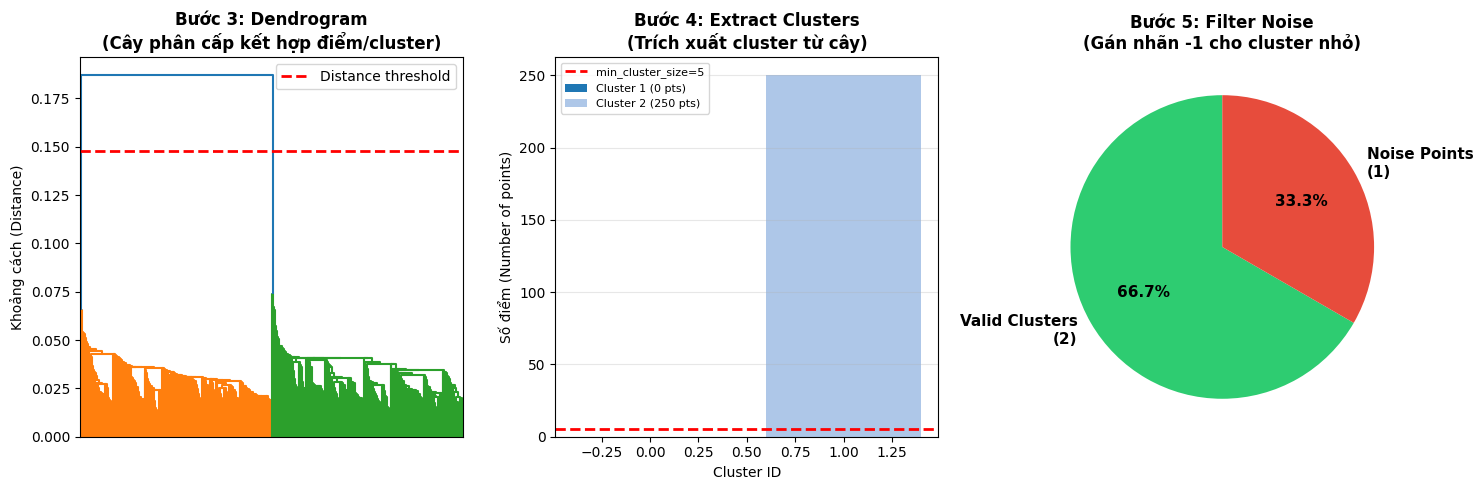

CHI TIẾT CÁC BƯỚC:

📊 BƯỚC 3 - Dendrogram:
  • Ma trận Z có kích thước: (499, 4)
  • Khoảng cách tối đa trên dendrogram: 0.1869

📊 BƯỚC 4 - Extract Clusters:
  • Ngưỡng khoảng cách (threshold): 0.1477
  • Số cluster tạm thời: 2
  • Phân bố cluster:
    - Cluster 1: 0 điểm
    - Cluster 2: 250 điểm

📊 BƯỚC 5 - Filter Noise:
  • min_cluster_size: 5
  • Cluster hợp lệ: 2 (≥ 5 điểm)
  • Noise points: 1 (< 5 điểm)
  • Tổng số điểm: 500


In [29]:
# Trực quan hóa các bước 3, 4, 5
from scipy.cluster.hierarchy import dendrogram
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# === BƯỚC 3: Dendrogram (Hierarchical Tree) ===
ax = axes[0]
# Tính lại Z để vẽ dendrogram
from scipy.spatial.distance import cdist, squareform
from scipy.cluster.hierarchy import linkage, fcluster

distances = cdist(X_scaled, X_scaled)
k_distances = np.sort(distances, axis=1)[:, 5]
core_distances = k_distances

mrd = np.zeros((X_scaled.shape[0], X_scaled.shape[0]))
for i in range(X_scaled.shape[0]):
    for j in range(X_scaled.shape[0]):
        if i != j:
            mrd[i, j] = max(distances[i, j], core_distances[i], core_distances[j])

mrd_condensed = squareform(mrd)
Z = linkage(mrd_condensed, method='single')

# Vẽ dendrogram
dendrogram(Z, ax=ax, no_labels=True, color_threshold=2*np.max(k_distances))
ax.axhline(y=2*np.max(k_distances), c='red', linestyle='--', linewidth=2, label='Distance threshold')
ax.set_title('Bước 3: Dendrogram\n(Cây phân cấp kết hợp điểm/cluster)', fontsize=12, fontweight='bold')
ax.set_ylabel('Khoảng cách (Distance)')
ax.legend()

# === BƯỚC 4: Extract Clusters ===
ax = axes[1]
clusters_temp = fcluster(Z, t=2*np.max(k_distances), criterion='distance')
cluster_counts = np.bincount(clusters_temp)

# Vẽ phân bố cluster trước lọc
colors_cluster = plt.cm.tab20(np.arange(len(np.unique(clusters_temp))))
for idx, (cluster_id, count) in enumerate(zip(np.unique(clusters_temp), cluster_counts)):
    ax.bar(idx, count, color=colors_cluster[idx], label=f'Cluster {cluster_id} ({count} pts)')

ax.axhline(y=5, c='red', linestyle='--', linewidth=2, label='min_cluster_size=5')
ax.set_xlabel('Cluster ID')
ax.set_ylabel('Số điểm (Number of points)')
ax.set_title('Bước 4: Extract Clusters\n(Trích xuất cluster từ cây)', fontsize=12, fontweight='bold')
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

# === BƯỚC 5: Filter Noise ===
ax = axes[2]
# Đếm cluster hợp lệ vs noise
valid_clusters = np.sum(cluster_counts >= 5)
noise_points = np.sum(cluster_counts < 5)
sizes = [valid_clusters, noise_points]
labels_pie = [f'Valid Clusters\n({valid_clusters})', f'Noise Points\n({noise_points})']
colors_pie = ['#2ecc71', '#e74c3c']

wedges, texts, autotexts = ax.pie(sizes, labels=labels_pie, colors=colors_pie, autopct='%1.1f%%',
                                     startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'})
ax.set_title('Bước 5: Filter Noise\n(Gán nhãn -1 cho cluster nhỏ)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# In thông tin chi tiết
print("="*60)
print("CHI TIẾT CÁC BƯỚC:")
print("="*60)
print(f"\n📊 BƯỚC 3 - Dendrogram:")
print(f"  • Ma trận Z có kích thước: {Z.shape}")
print(f"  • Khoảng cách tối đa trên dendrogram: {Z[-1, 2]:.4f}")
print(f"\n📊 BƯỚC 4 - Extract Clusters:")
print(f"  • Ngưỡng khoảng cách (threshold): {2*np.max(k_distances):.4f}")
print(f"  • Số cluster tạm thời: {len(np.unique(clusters_temp))}")
print(f"  • Phân bố cluster:")
for cid, count in zip(np.unique(clusters_temp), cluster_counts):
    print(f"    - Cluster {cid}: {count} điểm")

print(f"\n📊 BƯỚC 5 - Filter Noise:")
print(f"  • min_cluster_size: {5}")
print(f"  • Cluster hợp lệ: {valid_clusters} (≥ 5 điểm)")
print(f"  • Noise points: {noise_points} (< 5 điểm)")
print(f"  • Tổng số điểm: {len(labels)}")
print("="*60)

## Bảng so sánh: Trước và Sau các bước

| Bước | Đầu vào | Quá trình | Đầu ra | Mục đích |
|------|---------|----------|--------|---------|
| **3** | Mutual Reachability Distance Matrix | Xây dựng cây phân cấp bằng Single Linkage Clustering | Dendrogram (Z matrix) | Tạo cấu trúc phân cấp cho biết cách các điểm kết hợp |
| **4** | Dendrogram + Ngưỡng khoảng cách | Cắt cây tại ngưỡng `t = 2*max(k_distances)` | Nhãn cluster tạm thời | Chia điểm thành các cluster dựa trên khoảng cách |
| **5** | Nhãn cluster tạm thời | Lọc cluster có < min_cluster_size điểm | Nhãn final (với noise = -1) | Loại bỏ cluster quá nhỏ, chỉ giữ cluster có ý nghĩa |

---

## Code từng bước (Chi tiết hơn)

```python
# BƯỚC 3: Xây dựng Dendrogram
Z = linkage(mrd_condensed, method='single')
# Z[i] = [cluster_1, cluster_2, distance, num_points]
# Mỗi hàng = một bước kết hợp trong cây

# BƯỚC 4: Trích xuất Clusters từ Dendrogram
threshold = 2 * np.max(k_distances)
clusters_temp = fcluster(Z, t=threshold, criterion='distance')
# clusters_temp[i] = cluster_id của điểm thứ i
# Có thể còn cluster với 1-2 điểm (sẽ bị xóa ở bước 5)

# BƯỚC 5: Lọc Noise Points
self.labels_ = np.full(n_samples, -1)  # Gán tất cả = -1 (noise)
for cluster_label in np.unique(clusters_temp):
    members = np.where(clusters_temp == cluster_label)[0]
    if len(members) >= self.min_cluster_size:  # Nếu cluster đủ lớn
        self.labels_[members] = cluster_id    # Gán nhãn hợp lệ
        cluster_id += 1
    # else: Giữ nguyên -1 (noise)
```

---

## Ví dụ toàn bộ quy trình với 10 điểm:

```
Giả sử 10 điểm: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

BƯỚC 3: Dendrogram (Single Linkage)
─────────────────────────────────
0.15 → Gộp 1, 2
0.18 → Gộp {1,2}, 3
0.22 → Gộp 5, 6
0.25 → Gộp {5,6}, 7
0.30 → Gộp {1,2,3}, {0,4}
0.40 → Gộp {5,6,7}, 8
0.50 → Gộp {1,2,3,0,4}, {5,6,7,8}
0.60 → Gộp {...}, 9

BƯỚC 4: Cut tại threshold = 0.35
─────────────────────────────────
Cắt tại 0.35 (chỉ giữ edge < 0.35)
Cluster A: {0, 1, 2, 3, 4}    ← 5 điểm
Cluster B: {5, 6, 7, 8}       ← 4 điểm
Cluster C: {9}                ← 1 điểm

BƯỚC 5: Filter với min_cluster_size = 3
─────────────────────────────────────────
Cluster A: 5 ≥ 3 → Nhãn 0 ✓
Cluster B: 4 ≥ 3 → Nhãn 1 ✓
Cluster C: 1 < 3 → Nhãn -1 (noise) ✗

KẾT QUẢ CUỐI:
labels_ = [0, 0, 0, 0, 0, 1, 1, 1, 1, -1]
          └────────────────────────────┬─────────────────┘  └─┘
          Điểm hợp lệ                  Noise (outlier)
```

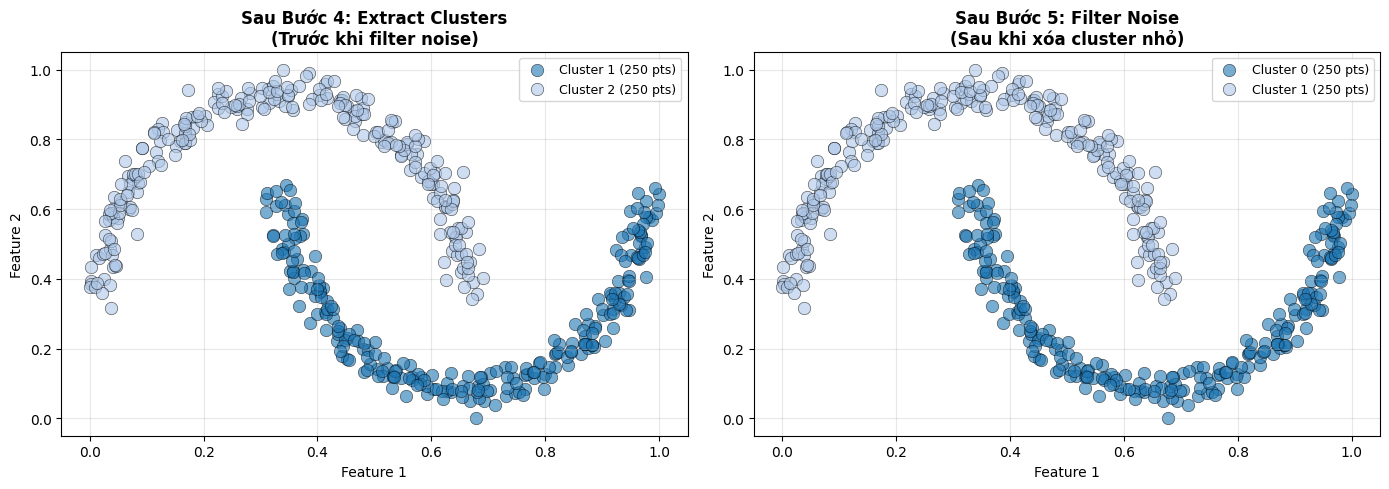


THỐNG KÊ CHI TIẾT: SAU BƯỚC 4 vs SAU BƯỚC 5

📊 SAU BƯỚC 4 (Extract Clusters):
   Số cluster (trước filter): 2
   Phân bố:
      ✓ Cluster 1: 250 điểm
      ✓ Cluster 2: 250 điểm

📊 SAU BƯỚC 5 (Filter Noise):
   Số cluster (sau filter): 1
   Cluster hợp lệ: 2
   Noise points: 0

   Phân bố nhãn cuối cùng:
      Cluster  0: 250 điểm
      Cluster  1: 250 điểm

🗑️  Số cluster bị loại bỏ: 1


In [30]:
# Trực quan: So sánh trước và sau Bước 5
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# === SAU BƯỚC 4 (Trước khi filter) ===
ax = axes[0]
clusters_before = clusters_temp
unique_before = np.unique(clusters_before)
colors_before = plt.cm.tab20(np.arange(len(unique_before)))

for label, color in zip(unique_before, colors_before):
    class_member_mask = (clusters_before == label)
    xy = X_scaled[class_member_mask]
    size_cluster = np.sum(class_member_mask)
    ax.scatter(xy[:, 0], xy[:, 1], c=[color], marker='o', s=80, alpha=0.6,
               label=f'Cluster {label} ({size_cluster} pts)', edgecolors='black', linewidth=0.5)

ax.set_title('Sau Bước 4: Extract Clusters\n(Trước khi filter noise)', fontsize=12, fontweight='bold')
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)

# === SAU BƯỚC 5 (Sau khi filter) ===
ax = axes[1]
clusters_after = labels
unique_after = np.unique(clusters_after)
colors_after = plt.cm.tab20(np.arange(len(unique_after)))

for label, color in zip(unique_after, colors_after):
    if label == -1:
        color = 'black'
        marker = 'x'
        size = 100
        label_text = 'Noise'
    else:
        marker = 'o'
        size = 80
        label_text = f'Cluster {label}'
    
    class_member_mask = (clusters_after == label)
    xy = X_scaled[class_member_mask]
    size_cluster = np.sum(class_member_mask)
    
    if label != -1:
        ax.scatter(xy[:, 0], xy[:, 1], c=[color], marker=marker, s=size, alpha=0.6,
                   label=f'{label_text} ({size_cluster} pts)', edgecolors='black', linewidth=0.5)
    else:
        ax.scatter(xy[:, 0], xy[:, 1], c=[color], marker=marker, s=size, alpha=0.7,
                   label=f'{label_text} ({size_cluster} pts)')

ax.set_title('Sau Bước 5: Filter Noise\n(Sau khi xóa cluster nhỏ)', fontsize=12, fontweight='bold')
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# === Thống kê chi tiết ===
print("\n" + "="*70)
print("THỐNG KÊ CHI TIẾT: SAU BƯỚC 4 vs SAU BƯỚC 5")
print("="*70)

print("\n📊 SAU BƯỚC 4 (Extract Clusters):")
print(f"   Số cluster (trước filter): {len(unique_before)}")
print(f"   Phân bố:")
for cid in unique_before:
    count = np.sum(clusters_before == cid)
    status = "✓" if count >= 5 else "✗"
    print(f"      {status} Cluster {cid}: {count:3d} điểm", end="")
    if count < 5:
        print(f" (sẽ bị xóa - quá nhỏ)")
    else:
        print()

print(f"\n📊 SAU BƯỚC 5 (Filter Noise):")
print(f"   Số cluster (sau filter): {len(unique_after) - 1}")  # -1 vì không tính noise
valid_count = len([l for l in unique_after if l != -1])
noise_count = np.sum(clusters_after == -1)
print(f"   Cluster hợp lệ: {valid_count}")
print(f"   Noise points: {noise_count}")
print(f"\n   Phân bố nhãn cuối cùng:")
for label in sorted(unique_after):
    count = np.sum(clusters_after == label)
    if label == -1:
        print(f"      Noise (-1): {count:3d} điểm ← Cluster < 5 điểm")
    else:
        print(f"      Cluster {label:2d}: {count:3d} điểm")

removed_clusters = len(unique_before) - len(unique_after) + 1  # +1 vì noise
print(f"\n🗑️  Số cluster bị loại bỏ: {removed_clusters}")
print("="*70)

# Giải thích Chi Tiết: Bước 3 - Xây dựng Cây Phân Cấp (Dendrogram)

## 📌 **Single Linkage Clustering là gì?**

Single Linkage (liên kết đơn) là một phương pháp xây dựng cây phân cấp bằng cách:
1. **Ban đầu**: Mỗi điểm là một cluster riêng biệt
2. **Bước lặp**: Kết hợp hai cluster có **khoảng cách tối thiểu** (gần nhất)
3. **Tiêp tục**: Cho đến khi tất cả điểm trong 1 cluster

### **Công thức tính khoảng cách (Single Linkage)**:
```
d(Cluster_A, Cluster_B) = min(d(a, b)) ∀a∈A, b∈B
                         = khoảng cách giữa cặp điểm gần nhất
```

**Ví dụ:**
```
Cluster A = {điểm 1, 2, 3}
Cluster B = {điểm 5, 6}

d(1,5)=0.15, d(1,6)=0.20
d(2,5)=0.18, d(2,6)=0.25
d(3,5)=0.12, d(3,6)=0.19

d(A, B) = min(0.15, 0.20, 0.18, 0.25, 0.12, 0.19) = 0.12 ← (điểm 3 và 5)
```

---

## 📊 **Quá trình Xây dựng Cây Phân Cấp (Step-by-Step)**

### **Khởi tạo (Ban đầu)**:
```
Giả sử 5 điểm: [0, 1, 2, 3, 4]
Khoảng cách từ Mutual Reachability Distance:

       0      1      2      3      4
   0   0    0.15   0.20   0.25   0.30
   1  0.15   0    0.18   0.22   0.35
   2  0.20  0.18    0    0.19   0.40
   3  0.25  0.22   0.19    0    0.45
   4  0.30  0.35   0.40   0.45    0
```

### **Bước 1: Tìm cặp điểm gần nhất**
```
Min distance = 0.15 (giữa điểm 0 và 1)
→ Kết hợp {0} + {1} = {0,1}

Cây hiện tại:
    {0,1}    {2}    {3}    {4}
      ↑  ↓
    0.15
      ↑  ↓
      0   1
```

### **Bước 2: Cập nhật khoảng cách với cluster mới**
```
d({0,1}, 2) = min(d(0,2), d(1,2)) = min(0.20, 0.18) = 0.18
d({0,1}, 3) = min(d(0,3), d(1,3)) = min(0.25, 0.22) = 0.22
d({0,1}, 4) = min(d(0,4), d(1,4)) = min(0.30, 0.35) = 0.30

Ma trận cập nhật:
           {0,1}  {2}   {3}   {4}
   {0,1}    0    0.18  0.22  0.30
   {2}     0.18   0    0.19  0.40
   {3}     0.22  0.19   0    0.45
   {4}     0.30  0.40  0.45   0
```

### **Bước 3: Tìm cặp gần nhất tiếp theo**
```
Min distance = 0.18 (giữa {0,1} và 2)
→ Kết hợp {0,1} + {2} = {0,1,2}

Cây hiện tại:
      {0,1,2}    {3}    {4}
       ↑  |  ↓
      /   |   \
   0.18  0.15  0.15
    |     |     |
    2     0     1
```

### **Bước 4: Tiếp tục...**
```
d({0,1,2}, 3) = min(d({0,1},3), d(2,3)) = min(0.22, 0.19) = 0.19
d({0,1,2}, 4) = min(d({0,1},4), d(2,4)) = min(0.30, 0.40) = 0.30

Min distance = 0.19 (giữa {0,1,2} và 3)
→ Kết hợp {0,1,2} + {3} = {0,1,2,3}
```

### **Bước 5: Kết hợp cuối cùng**
```
d({0,1,2,3}, 4) = min(d({0,1,2},4), d(3,4)) = min(0.30, 0.45) = 0.30
→ Kết hợp {0,1,2,3} + {4}

CẬY PHÂN CẤP HOÀN CHỈNH:
                    
            0.30 ─────────┐
                          ├─ {0,1,2,3,4}
            0.19 ─┐       │
                  ├─ {0,1,2,3}
            0.18 ┐└─ {2}  │
                 │   ├──2 │
            0.15 ├─ {0,1} │
                 │  │    │
                 │  0    1
                 │        
                 └─ {3}
                    │
                    3
                    
                 {4}
                  │
                  4
```

---

## 🔢 **Ma trận Linkage Z (Output)**

Mỗi hàng của Z đại diện cho một bước kết hợp:
```
Z = [[i, j, distance, num_samples], ...]
     ↑  ↑    ↑         ↑
     │  │    │         └─ Số điểm trong cluster kết hợp
     │  │    └────────── Khoảng cách giữa hai cluster
     │  └────────────── Index của cluster thứ 2
     └────────────── Index của cluster thứ 1
```

**Ví dụ với 5 điểm:**
```
Z[0] = [0,  1,  0.15, 2]   ← Bước 1: Kết hợp 0 + 1 (distance=0.15, 2 điểm)
Z[1] = [5,  2,  0.18, 3]   ← Bước 2: Kết hợp cluster từ Z[0] với 2 (distance=0.18, 3 điểm)
                              [5 là index cluster mới từ Z[0]]
Z[2] = [6,  3,  0.19, 4]   ← Bước 3: Kết hợp cluster từ Z[1] với 3 (distance=0.19, 4 điểm)
Z[3] = [7,  4,  0.30, 5]   ← Bước 4: Kết hợp cluster từ Z[2] với 4 (distance=0.30, 5 điểm)
```

### **Giải thích Index:**
```
Khi n_samples = 5:
- Các điểm gốc: index 0, 1, 2, 3, 4
- Cluster mới sau mỗi bước linkage: index từ 5 trở đi

Z[0] = [0, 1, 0.15, 2]
  → Kết hợp điểm 0 + 1 → tạo cluster 5

Z[1] = [5, 2, 0.18, 3]
  → Kết hợp cluster 5 (từ Z[0]) + điểm 2 → tạo cluster 6

Z[2] = [6, 3, 0.19, 4]
  → Kết hợp cluster 6 (từ Z[1]) + điểm 3 → tạo cluster 7

Z[3] = [7, 4, 0.30, 5]
  → Kết hợp cluster 7 (từ Z[2]) + điểm 4 → tạo cluster 8
```

---

## 🎯 **Tóm tắt Quá trình**

| Bước | Hành động | Khoảng cách | Cluster mới |
|------|-----------|-----------|-------------|
| 0 | Mỗi điểm một cluster | - | {0}, {1}, {2}, {3}, {4} |
| 1 | Kết hợp 0+1 (min=0.15) | 0.15 | {0,1}, {2}, {3}, {4} |
| 2 | Kết hợp {0,1}+2 (min=0.18) | 0.18 | {0,1,2}, {3}, {4} |
| 3 | Kết hợp {0,1,2}+3 (min=0.19) | 0.19 | {0,1,2,3}, {4} |
| 4 | Kết hợp {0,1,2,3}+4 (min=0.30) | 0.30 | {0,1,2,3,4} |

---

## 📈 **Chiều cao các gốc trong dendrogram**

Chiều cao = khoảng cách tại mỗi bước kết hợp
```
Cao nhất: 0.30 (bước cuối)
          │
       0.30│     ╱
          │    ╱
       0.19│  ╱────
          │ ╱      \
       0.18│╱────┐  \
          │     │   \
       0.15│──┐ │    \
          ├──┼─┼─────┤
          0  1 2  3   4 (điểm gốc)
```

MA TRẬN LINKAGE Z - CHI TIẾT TỪNG BƯỚC

Cấu trúc: [cluster_1_index, cluster_2_index, distance, num_samples]

--------------------------------------------------------------------------------
Z[0] = [2, 5, 0.5835, 2]
     ↓ Kết hợp: Điểm 2 + Điểm 5
     ↓ Khoảng cách: 0.5835
     ↓ Cluster mới (2 điểm) → Index 6
--------------------------------------------------------------------------------
Z[1] = [1, 6, 0.7129, 3]
     ↓ Kết hợp: Điểm 1 + Cluster từ Z[0]
     ↓ Khoảng cách: 0.7129
     ↓ Cluster mới (3 điểm) → Index 7
--------------------------------------------------------------------------------
Z[2] = [3, 7, 0.7292, 4]
     ↓ Kết hợp: Điểm 3 + Cluster từ Z[1]
     ↓ Khoảng cách: 0.7292
     ↓ Cluster mới (4 điểm) → Index 8
--------------------------------------------------------------------------------
Z[3] = [0, 8, 0.7471, 5]
     ↓ Kết hợp: Điểm 0 + Cluster từ Z[2]
     ↓ Khoảng cách: 0.7471
     ↓ Cluster mới (5 điểm) → Index 9
----------------------------------------------------

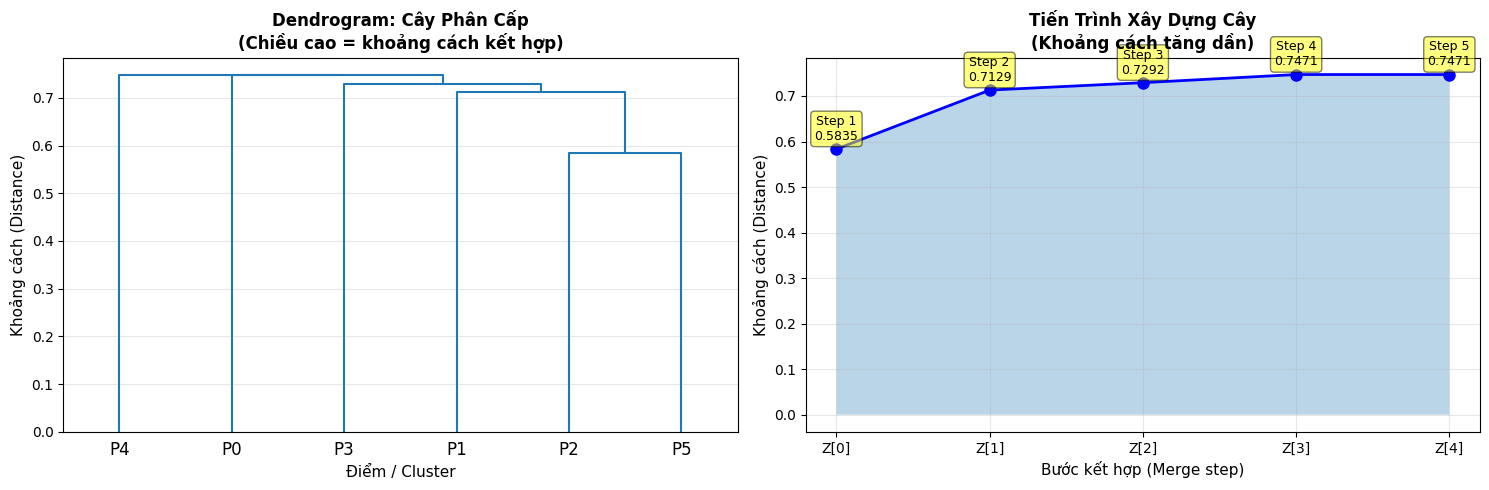


THỐNG KÊ QUÁ TRÌNH LINKAGE
Số điểm: 6
Số bước kết hợp: 5
Khoảng cách min: 0.5835
Khoảng cách max: 0.7471
Khoảng cách trung bình: 0.7040


In [ ]:
# Trực quan hóa: Quá trình xây dựng cây phân cấp từng bước
# Lấy 6 điểm để dễ theo dõi
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, dendrogram

# Lấy 6 điểm đầu tiên từ dữ liệu
X_sample = X_scaled[:6]

# Tính mutual reachability distance
distances_sample = cdist(X_sample, X_sample)
k_distances_sample = np.sort(distances_sample, axis=1)[:, 5]  # k=5 cho 6 điểm
core_distances_sample = k_distances_sample

mrd_sample = np.zeros((6, 6))
for i in range(6):
    for j in range(6):
        if i != j:
            mrd_sample[i, j] = max(distances_sample[i, j], core_distances_sample[i], core_distances_sample[j])

# Tính linkage
mrd_condensed_sample = squareform(mrd_sample)
Z_sample = linkage(mrd_condensed_sample, method='single')

# In ma trận Z chi tiết
print("="*80)
print("MA TRẬN LINKAGE Z - CHI TIẾT TỪNG BƯỚC")
print("="*80)
print("\nCấu trúc: [cluster_1_index, cluster_2_index, distance, num_samples]")
print("\n" + "-"*80)

for idx, row in enumerate(Z_sample):
    i, j, dist, num_pts = int(row[0]), int(row[1]), row[2], int(row[3])
    
    # Xác định tên cluster
    if i < 6:
        cluster_i = f"Điểm {i}"
    else:
        cluster_i = f"Cluster từ Z[{i-6}]"
    
    if j < 6:
        cluster_j = f"Điểm {j}"
    else:
        cluster_j = f"Cluster từ Z[{j-6}]"
    
    print(f"Z[{idx}] = [{i}, {j}, {dist:.4f}, {int(num_pts)}]")
    print(f"     ↓ Kết hợp: {cluster_i} + {cluster_j}")
    print(f"     ↓ Khoảng cách: {dist:.4f}")
    print(f"     ↓ Cluster mới ({int(num_pts)} điểm) → Index {6+idx}")
    print("-"*80)

# Vẽ dendrogram
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Biểu đồ 1: Dendrogram đầy đủ
ax = axes[0]
dendro = dendrogram(Z_sample, ax=ax, labels=[f'P{i}' for i in range(6)])
ax.set_title('Dendrogram: Cây Phân Cấp\n(Chiều cao = khoảng cách kết hợp)', 
             fontsize=12, fontweight='bold')
ax.set_ylabel('Khoảng cách (Distance)', fontsize=11)
ax.set_xlabel('Điểm / Cluster', fontsize=11)
ax.grid(axis='y', alpha=0.3)

# Biểu đồ 2: Lịch sử khoảng cách
ax = axes[1]
distances_linkage = Z_sample[:, 2]
steps = np.arange(len(distances_linkage))
ax.plot(steps, distances_linkage, 'b-o', linewidth=2, markersize=8, label='Khoảng cách kết hợp')
ax.fill_between(steps, distances_linkage, alpha=0.3)

# Đánh dấu từng bước
for idx, (step, dist) in enumerate(zip(steps, distances_linkage)):
    ax.annotate(f'Step {idx+1}\n{dist:.4f}', 
                xy=(step, dist), 
                xytext=(step, dist + 0.02),
                ha='center', fontsize=9,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.5))

ax.set_xlabel('Bước kết hợp (Merge step)', fontsize=11)
ax.set_ylabel('Khoảng cách (Distance)', fontsize=11)
ax.set_title('Tiến Trình Xây Dựng Cây\n(Khoảng cách tăng dần)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_xticks(steps)
ax.set_xticklabels([f'Z[{i}]' for i in range(len(steps))])

plt.tight_layout()
plt.show()

# In thống kê
print("\n" + "="*80)
print("THỐNG KÊ QUÁ TRÌNH LINKAGE")
print("="*80)
print(f"Số điểm: 6")
print(f"Số bước kết hợp: {len(Z_sample)}")
print(f"Khoảng cách min: {Z_sample[:, 2].min():.4f}")
print(f"Khoảng cách max: {Z_sample[:, 2].max():.4f}")
print(f"Khoảng cách trung bình: {Z_sample[:, 2].mean():.4f}")
print("="*80)


SO SÁNH CÁC PHƯƠNG PHÁP LINKAGE


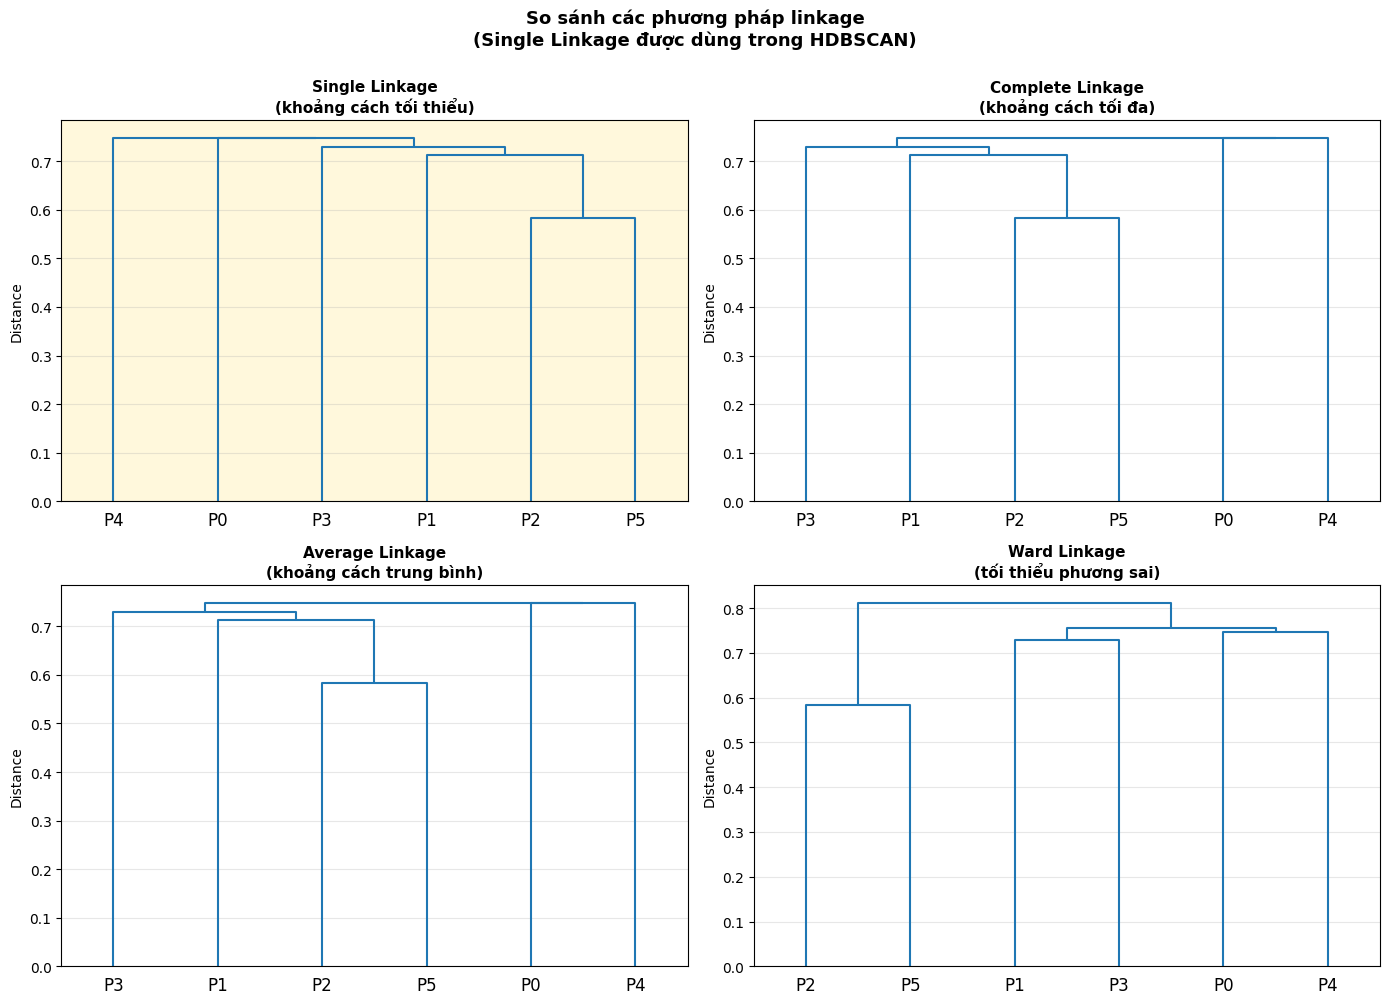


📊 CHI TIẾT CÁC PHƯƠNG PHÁP LINKAGE:

────────────────────────────────────────────────────────────────────────────────
                     Single Linkage
(khoảng cách tối thiểu)                     
────────────────────────────────────────────────────────────────────────────────

CÔNG THỨC: d(A,B) = min(d(a,b)) ∀a∈A, b∈B
ƯUTHẾ: Tìm cặp điểm gần nhất giữa hai cluster

KỲ VỌNG: 
  ✓ Phát hiện cluster dài, liên tục (chain-like)
  ✓ Nhạy cảm với mối liên kết giữa cluster
  ✓ Phù hợp với HDBSCAN (dữ liệu có mật độ biến thiên)

NHƯỢC ĐIỂM:
  ✗ Có thể tạo "chaining effect" (quá nhiều điểm liên thông)
  ✗ Dễ kết hợp cluster nên không nên (nếu không cẩn thận)
        
Khoảng cách min: 0.5835
Khoảng cách max: 0.7471
Khoảng cách trung bình: 0.7040

────────────────────────────────────────────────────────────────────────────────
                     Complete Linkage
(khoảng cách tối đa)                      
────────────────────────────────────────────────────────────────────────────────

CÔNG TH

In [33]:
print("\n" + "="*80)
print("SO SÁNH CÁC PHƯƠNG PHÁP LINKAGE")
print("="*80)

# Tính linkage với các phương pháp khác nhau
linkage_methods = {
    'single': 'Single Linkage\n(khoảng cách tối thiểu)',
    'complete': 'Complete Linkage\n(khoảng cách tối đa)',
    'average': 'Average Linkage\n(khoảng cách trung bình)',
    'ward': 'Ward Linkage\n(tối thiểu phương sai)',
}

Z_methods = {}
for method in linkage_methods.keys():
    Z_methods[method] = linkage(mrd_condensed_sample, method=method)

# Vẽ so sánh
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (method, name) in enumerate(linkage_methods.items()):
    ax = axes[idx]
    dendro = dendrogram(Z_methods[method], ax=ax, labels=[f'P{i}' for i in range(6)])
    ax.set_title(f'{name}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Distance')
    ax.grid(axis='y', alpha=0.3)
    
    # Highlight Single Linkage
    if method == 'single':
        ax.set_facecolor('#fff8dc')  # Cornsilk color

plt.suptitle('So sánh các phương pháp linkage\n(Single Linkage được dùng trong HDBSCAN)', 
             fontsize=13, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

# In chi tiết so sánh
print("\n📊 CHI TIẾT CÁC PHƯƠNG PHÁP LINKAGE:\n")

for method, name in linkage_methods.items():
    Z = Z_methods[method]
    print(f"{'─'*80}")
    print(f"{name}".center(80))
    print(f"{'─'*80}")
    
    if method == 'single':
        desc = """
CÔNG THỨC: d(A,B) = min(d(a,b)) ∀a∈A, b∈B
ƯUTHẾ: Tìm cặp điểm gần nhất giữa hai cluster

KỲ VỌNG: 
  ✓ Phát hiện cluster dài, liên tục (chain-like)
  ✓ Nhạy cảm với mối liên kết giữa cluster
  ✓ Phù hợp với HDBSCAN (dữ liệu có mật độ biến thiên)
  
NHƯỢC ĐIỂM:
  ✗ Có thể tạo "chaining effect" (quá nhiều điểm liên thông)
  ✗ Dễ kết hợp cluster nên không nên (nếu không cẩn thận)
        """
    elif method == 'complete':
        desc = """
CÔNG THỨC: d(A,B) = max(d(a,b)) ∀a∈A, b∈B
ƯUTHẾ: Tìm cặp điểm xa nhất giữa hai cluster

KỲ VỌNG:
  ✓ Tạo cluster compact, gọn gàng
  ✓ Tránh chaining effect
  
NHƯỢC ĐIỂM:
  ✗ Quá strict, dễ bị outlier ảnh hưởng
  ✗ Không phù hợp với dữ liệu có mật độ biến thiên
        """
    elif method == 'average':
        desc = """
CÔNG THỨC: d(A,B) = Σd(a,b) / (|A|*|B|)
ƯUTHẾ: Lấy trung bình khoảng cách

KỲ VỌNG:
  ✓ Cân bằng giữa Single và Complete
  ✓ Khá ổn định
  
NHƯỢC ĐIỂM:
  ✗ Chậm hơn (phải tính tất cả cặp)
        """
    else:  # ward
        desc = """
CÔNG THỨC: Dựa trên việc tối thiểu hóa phương sai (variance)
ƯUTHẾ: Tạo cluster với phương sai nhỏ

KỲ VỌNG:
  ✓ Cluster rất compact
  ✓ Phổ biến trong thống kê
  
NHƯỢC ĐIỂM:
  ✗ Không phù hợp với HDBSCAN (không dùng Mutual Reachability)
  ✗ Giả định cluster spherical (hình cầu)
        """
    
    print(desc)
    print(f"Khoảng cách min: {Z[:, 2].min():.4f}")
    print(f"Khoảng cách max: {Z[:, 2].max():.4f}")
    print(f"Khoảng cách trung bình: {Z[:, 2].mean():.4f}\n")

print("="*80)
print("✅ KẾT LUẬN: HDBSCAN dùng SINGLE LINKAGE vì:")
print("   • Phát hiện cluster có mật độ khác nhau tốt")
print("   • Hoạt động tốt với Mutual Reachability Distance")
print("   • Phù hợp với cấu trúc dữ liệu không đều")
print("="*80)

## 🎯 **Tóm tắt: Cách lấy cây phân cấp trong HDBSCAN**

### **Input → Process → Output**

```
┌──────────────────────────────────────────────────────────┐
│ INPUT: Ma trận Mutual Reachability Distance (MRD)        │
│        n_samples × n_samples                             │
└──────────────────────────────────────────────────────────┘
                           ↓
┌──────────────────────────────────────────────────────────┐
│ BƯỚC 3: Single Linkage Clustering                        │
│                                                          │
│ 1. Khởi tạo: Mỗi điểm = 1 cluster                       │
│ 2. Lặp lại:                                              │
│    • Tìm 2 cluster có khoảng cách MIN (Single Linkage)  │
│    • Kết hợp chúng                                       │
│    • Cập nhật khoảng cách với các cluster khác          │
│    • Lưu thông tin kết hợp vào ma trận Z                │
│ 3. Dừng khi tất cả trong 1 cluster                      │
└──────────────────────────────────────────────────────────┘
                           ↓
┌──────────────────────────────────────────────────────────┐
│ OUTPUT: Ma trận Linkage Z                                │
│        (n_samples-1) × 4                                │
│        [cluster_1, cluster_2, distance, num_points]     │
└──────────────────────────────────────────────────────────┘
                           ↓
        ┌────── được dùng trong Bước 4┐
        │  Cắt cây tại threshold để   │
        │  trích xuất clusters        │
        └────────────────────────────┘
```

### **Công thức Single Linkage (trong HDBSCAN)**

```python
# Code từ HDBSCAN
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage

# 1. Convert ma trận đầy đủ → Condensed distance format
mrd_condensed = squareform(mrd)  # Chỉ lấy phần tam giác dưới

# 2. Áp dụng Single Linkage Clustering
Z = linkage(mrd_condensed, method='single')

# 3. Z chứa toàn bộ lịch sử kết hợp từng bước
```

### **Ví dụ cụ thể với ma trận 4×4:**

```
MRD Matrix:
       P0    P1    P2    P3
P0  [  0   0.15  0.20  0.25 ]
P1  [0.15  0    0.18  0.22 ]
P2  [0.20 0.18   0    0.19 ]
P3  [0.25 0.22  0.19   0   ]

Quá trình Single Linkage:
═══════════════════════════════════════════════════════════

Bước 0 (Khởi tạo):
  {P0}  {P1}  {P2}  {P3}

Bước 1: Min = 0.15 (P0-P1) → Kết hợp
  {P0,P1}  {P2}  {P3}
  Z[0] = [0, 1, 0.15, 2]

Bước 2: Min = 0.18 ({P0,P1}-P2) → Kết hợp
  {P0,P1,P2}  {P3}
  Z[1] = [4, 2, 0.18, 3]  [4 = index cluster từ Z[0]]

Bước 3: Min = 0.19 ({P0,P1,P2}-P3) → Kết hợp
  {P0,P1,P2,P3}
  Z[2] = [5, 3, 0.19, 4]  [5 = index cluster từ Z[1]]

Kết quả Z:
[
  [0, 1, 0.15, 2],
  [4, 2, 0.18, 3],
  [5, 3, 0.19, 4],
]
```

### **Giải thích từng cột của Z:**

```
    Cột 0: Index cluster A        
    Cột 1: Index cluster B        
    Cột 2: Khoảng cách giữa A và B  
    Cột 3: Số điểm trong cluster kết hợp
    
Ví dụ: [0, 1, 0.15, 2]
       └─┬─┘ └─┬─┘ └────┬────┘ └────┬─────┘
         │     │   0.15 điểm  │    2 điểm
         │     │ (Single Link)│
         │     └─ Điểm 1
         └────── Điểm 0
```

### **Tại sao Single Linkage?**

**HDBSCAN = **H**ierarchical **DBSCAN****

- DBSCAN tìm cluster bằng **kết nối bậc k** (k-nearest neighbors)
- Single Linkage cũng dùng **kết nối tối thiểu**
- Cả hai cùng focus vào điểm **gần nhất** → Phù hợp nhau!

| Tiêu chí | Single Linkage | Complete Linkage | Average |
|----------|----------------|------------------|---------|
| Dùng điểm | Gần nhất | Xa nhất | Trung bình |
| Phù hợp HDBSCAN | ✅ | ❌ | ⚠️ |
| Phát hiện cluster dài | ✅ | ❌ | ⚠️ |
| Mật độ biến thiên | ✅ | ❌ | ⚠️ |